# COVID-19 Prediction Using Stateful LSTM (Timeseries/Forecast Prediction)

Procedure:

1. Preparing requirements
2. Getting dataset
3. Preparing functions
4. Preparing data & model
5. Testing the model before going to the future prediction
6. Doing future prediction


Note: <u><i>Maybe I did it with some mistake, please show me how to do it better</i></u>

## Preparing requirements

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.callbacks import EarlyStopping

Using TensorFlow backend.


In [2]:
RANDOM_SEED = 42
TRAIN_CASE = 'new_cases'
TRAIN_LOCATION = 'Indonesia'
DATATRAIN_SOURCE_FILE = 'covid19_full_data.csv'
TEST_SIZE = 0.3
LOOK_BACK = 1
DIFF_INTERVAL = 1
BATCH_SIZE = 1
EPOCHS = 2000
DAYS_TO_PREDICT = 60

In [3]:
np.random.seed(RANDOM_SEED)

## Getting dataset

In [4]:
df = pd.read_csv(DATATRAIN_SOURCE_FILE)
if TRAIN_LOCATION:
    df = df.loc[df['location']==TRAIN_LOCATION]
df.drop(['location'], axis=1, inplace=True)
df.set_index('date', inplace=True)
df.index = pd.to_datetime(df.index)

In [5]:
df.head()

,new_cases,new_deaths,total_cases,total_deaths
date,,,,
2019-12-31,0,0,0,0
2020-01-01,0,0,0,0
2020-01-02,0,0,0,0
2020-01-03,0,0,0,0
2020-01-04,0,0,0,0


Gettin train case & removing all zero values

In [6]:
cases = df.filter([TRAIN_CASE])
cases = cases[(cases.T != 0).any()]

In [7]:
cases.head()

,new_cases
date,
2020-03-02,2
2020-03-07,2
2020-03-09,2
2020-03-11,13
2020-03-12,15


Plotting train case data

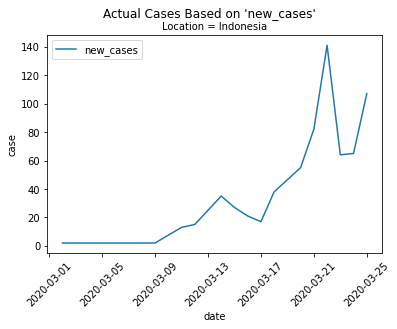

In [8]:
plt.suptitle('Actual Cases Based on \'' + TRAIN_CASE + '\'')
plt.title('Location = ' + TRAIN_LOCATION, fontsize='medium')
plt.plot(cases, label=TRAIN_CASE)
plt.xlabel('date')
plt.ylabel('case')
plt.xticks(rotation=45)
plt.legend()
plt.show()
plt.show()

In [9]:
cases.shape

(16, 1)

## Preparing functions

This will split data into X & Y value

In [10]:
def data_split(data, look_back=1):
    x, y = [], []
    for i in range(len(data) - look_back - 1):
        a = data[i:(i + look_back), 0]
        x.append(a)
        y.append(data[i + look_back, 0])
    return np.array(x), np.array(y)

In [11]:
def difference(data, diff_interval=1):
    diff = list()
    for i in range(diff_interval, len(data)):
        value = data[i] - data[i - diff_interval]
        diff.append(value)
    return pd.Series(diff)

In [12]:
def inverse_difference(data, last_observed):
    inverted = list()
    inverted.append(data[0] + last_observed)
    for i in range(1, len(data)):
        inverted.append(data[i] + inverted[i-1])
    return np.array(inverted)

## Preparing data & model

In [13]:
cases.head()

,new_cases
date,
2020-03-02,2
2020-03-07,2
2020-03-09,2
2020-03-11,13
2020-03-12,15


In [14]:
diff_interval = DIFF_INTERVAL
diff_cases = difference(cases.values.flatten())
diff_cases.index = cases.index[diff_interval:]
diff_cases_index = diff_cases.index

In [15]:
diff_cases.head()

date
2020-03-07     0
2020-03-09     0
2020-03-11    11
2020-03-12     2
2020-03-14    20
dtype: int64

In [16]:
t_inverse_diff = inverse_difference(diff_cases, cases.values.flatten()[0])
t_inverse_diff = pd.Series(t_inverse_diff)
t_inverse_diff.index = diff_cases.index

In [17]:
t_inverse_diff.head()

date
2020-03-07     2
2020-03-09     2
2020-03-11    13
2020-03-12    15
2020-03-14    35
dtype: int64

In [18]:
diff_cases = np.array(diff_cases).reshape(len(diff_cases), 1)

In [19]:
diff_cases.shape

(15, 1)

Creating train & test data for testing

In [20]:
test_size = TEST_SIZE
test_size = int(diff_cases.shape[0] * test_size)
train_cases = diff_cases[:-test_size]
train_cases = np.array(train_cases).reshape(len(train_cases), 1)
test_cases = diff_cases[-test_size:]
test_cases = np.array(test_cases).reshape(len(test_cases), 1)

In [21]:
train_cases[:5]

array([[ 0],
       [ 0],
       [11],
       [ 2],
       [20]])

In [22]:
train_cases.shape

(11, 1)

In [23]:
test_cases

array([[ 59],
       [-77],
       [  1],
       [ 42]])

In [24]:
test_cases.shape

(4, 1)

Data normalization

In [25]:
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler = scaler.fit(diff_cases)
all_cases = scaler.transform(diff_cases)
train_cases = scaler.transform(train_cases)
test_cases = scaler.transform(test_cases)

In [26]:
all_cases[:5]

array([[0.13235294],
       [0.13235294],
       [0.29411765],
       [0.16176471],
       [0.42647059]])

In [27]:
all_cases.shape

(15, 1)

In [28]:
train_cases[:5]

array([[0.13235294],
       [0.13235294],
       [0.29411765],
       [0.16176471],
       [0.42647059]])

In [29]:
train_cases.shape

(11, 1)

In [30]:
test_cases[:5]

array([[ 1.        ],
       [-1.        ],
       [ 0.14705882],
       [ 0.75      ]])

In [31]:
test_cases.shape

(4, 1)

Splitting data to get X & Y value

In [32]:
look_back = LOOK_BACK
X_all, Y_all = data_split(all_cases, look_back=look_back)
X_train, Y_train = data_split(train_cases, look_back=look_back)
X_test, Y_test = data_split(test_cases, look_back=look_back)

In [33]:
X_all[:5]

array([[0.13235294],
       [0.13235294],
       [0.29411765],
       [0.16176471],
       [0.42647059]])

In [34]:
X_all.shape

(13, 1)

In [35]:
Y_all[:5]

array([0.13235294, 0.29411765, 0.16176471, 0.42647059, 0.01470588])

In [36]:
X_train[:5]

array([[0.13235294],
       [0.13235294],
       [0.29411765],
       [0.16176471],
       [0.42647059]])

In [37]:
X_train.shape

(9, 1)

In [38]:
Y_train[:5]

array([0.13235294, 0.29411765, 0.16176471, 0.42647059, 0.01470588])

In [39]:
X_test[:5]

array([[ 1.],
       [-1.]])

In [40]:
X_test.shape

(2, 1)

In [41]:
Y_test[:5]

array([-1.        ,  0.14705882])

In [42]:
X_all_inverse = scaler.inverse_transform(
    np.array(X_all).reshape(X_all.shape[0], 1)
)
X_all_inverse_diff = inverse_difference(X_all_inverse, cases.values.flatten()[0])

In [43]:
X_all_inverse[:5]

array([[ 0.],
       [ 0.],
       [11.],
       [ 2.],
       [20.]])

In [44]:
X_all_inverse.shape

(13, 1)

In [45]:
X_all_inverse_diff[:5]

array([[ 2.],
       [ 2.],
       [13.],
       [15.],
       [35.]])

In [46]:
X_all_inverse_diff.shape

(13, 1)

We need to convert the shape of the data to LSTM shape format (samples, timesteps, features)

To make a model can learning from a sequence, we'll using timesteps for timeseries prediction

In [47]:
X_all = np.array(X_all).reshape(X_all.shape[0], 1, 1)
Y_all = np.array(Y_all).reshape(Y_all.shape[0], 1)
X_train = np.array(X_train).reshape(X_train.shape[0], 1, 1)
Y_train = np.array(Y_train).reshape(Y_train.shape[0], 1)
X_test = np.array(X_test).reshape(X_test.shape[0], 1, 1)
Y_test = np.array(Y_test).reshape(Y_test.shape[0], 1)

In [48]:
X_all[:5]

array([[[0.13235294]],

       [[0.13235294]],

       [[0.29411765]],

       [[0.16176471]],

       [[0.42647059]]])

In [49]:
X_all.shape

(13, 1, 1)

In [50]:
Y_all.shape

(13, 1)

In [51]:
X_train[:5]

array([[[0.13235294]],

       [[0.13235294]],

       [[0.29411765]],

       [[0.16176471]],

       [[0.42647059]]])

In [52]:
X_train.shape

(9, 1, 1)

In [53]:
Y_train.shape

(9, 1)

In [54]:
X_test[:5]

array([[[ 1.]],

       [[-1.]]])

In [55]:
X_test.shape

(2, 1, 1)

In [56]:
Y_test.shape

(2, 1)

And, this is the LSTM timeseries prediction model

In [57]:
batch_size = BATCH_SIZE
model = Sequential()
model.add(LSTM(8, return_sequences=True, 
               batch_input_shape=(batch_size, X_train.shape[1], X_train.shape[2]), 
               stateful=True))
model.add(LSTM(1, return_sequences=False, stateful=True))
model.add(Dense(Y_train.shape[1]))
model.compile(loss='mean_squared_error', optimizer='adam')
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_1 (LSTM)                (1, 1, 8)                 320       
_________________________________________________________________
lstm_2 (LSTM)                (1, 1)                    40        
_________________________________________________________________
dense_1 (Dense)              (1, 1)                    2         
Total params: 362
Trainable params: 362
Non-trainable params: 0
_________________________________________________________________
None


## Testing the model before going to the future prediction

Fitting the model with train data

In [58]:
epoch = EPOCHS
loss = []
for i in range(epoch):
    print('Iteration ' + str(i + 1) + '/' + str(epoch))
    model.fit(X_train, Y_train, batch_size=batch_size, 
              epochs=1, verbose=1, shuffle=False, 
              callbacks=[EarlyStopping(monitor='loss', mode='min', verbose=1)])
    h = model.history
    loss.append(h.history['loss'][0])
    model.reset_states()

Iteration 1/2000
Epoch 1/1
9/9 [==============================] - 1s 61ms/step - loss: 0.0486
Iteration 2/2000
Epoch 1/1
9/9 [==============================] - 0s 3ms/step - loss: 0.0414
Iteration 3/2000
Epoch 1/1
9/9 [==============================] - 0s 2ms/step - loss: 0.0362
Iteration 4/2000
Epoch 1/1
9/9 [==============================] - 0s 2ms/step - loss: 0.0329
Iteration 5/2000
Epoch 1/1
9/9 [==============================] - 0s 2ms/step - loss: 0.0311
Iteration 6/2000
Epoch 1/1
9/9 [==============================] - 0s 2ms/step - loss: 0.0303
Iteration 7/2000
Epoch 1/1
9/9 [==============================] - 0s 2ms/step - loss: 0.0300
Iteration 8/2000
Epoch 1/1
9/9 [==============================] - 0s 4ms/step - loss: 0.0299
Iteration 9/2000
Epoch 1/1
9/9 [==============================] - 0s 2ms/step - loss: 0.0299
Iteration 10/2000
Epoch 1/1
9/9 [==============================] - 0s 2ms/step - loss: 0.0298
Iteration 11/2000
Epoch 1/1
9/9 [==============================] - 0

Plotting model loss history

Lower `loss` provides better prediction

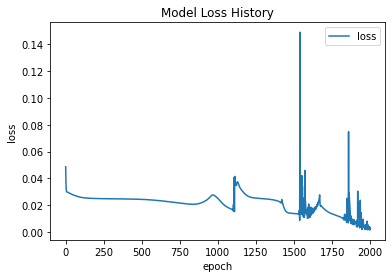

In [59]:
plt.plot(loss, label='loss')
plt.title('Model Loss History')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

Predicting with train data

This will also set prediction input (previous input) into LSTM state which is useful to predict future value

In [60]:
train_predict = model.predict(X_train, batch_size=batch_size)
X_train_inverse = scaler.inverse_transform(
    np.array(X_train).reshape(X_train.shape[0], 1)
)
X_train_inverse_diff = inverse_difference(X_train_inverse, cases.values.flatten()[0])
train_predict_inverse = scaler.inverse_transform(train_predict)
train_predict_inverse_diff = inverse_difference(train_predict_inverse, 
                                                X_train_inverse_diff[:1].flatten())

In [61]:
X_train_inverse[:5]

array([[ 0.],
       [ 0.],
       [11.],
       [ 2.],
       [20.]])

In [62]:
X_train_inverse_diff

array([[ 2.],
       [ 2.],
       [13.],
       [15.],
       [35.],
       [27.],
       [21.],
       [17.],
       [38.]])

In [63]:
train_predict[:5]

array([[0.18864077],
       [0.22060299],
       [0.17106612],
       [0.43936583],
       [0.04681781]], dtype=float32)

In [64]:
train_predict_inverse[:5]

array([[ 3.8275726],
       [ 6.0010033],
       [ 2.632496 ],
       [20.876877 ],
       [-5.816389 ]], dtype=float32)

In [65]:
train_predict_inverse_diff[:5]

array([[ 5.82757258],
       [11.82857585],
       [14.46107197],
       [35.3379488 ],
       [29.52155972]])

In [66]:
# model.reset_states()

In [67]:
train_predict_score = math.sqrt(
    mean_squared_error(
        X_train_inverse_diff, 
        train_predict_inverse_diff
    )
)

In [68]:
'Train Score: %.2f RMSE' % (train_predict_score)

'Train Score: 14.38 RMSE'

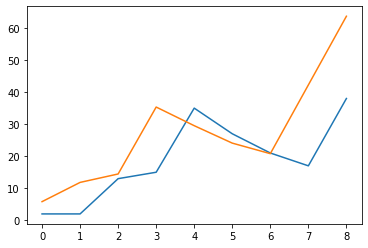

In [69]:
plt.plot(X_train_inverse_diff.flatten())
plt.plot(train_predict_inverse_diff.flatten())

Predicting future value based on test data

In [70]:
days_to_predict = X_test.shape[0]
test_predict = []
pred_samples = train_predict[-1:]
pred_samples = np.array([pred_samples])
for i in range(days_to_predict):
    pred = model.predict(X_test[i:(i+1)], batch_size=batch_size)
    pred = np.array(pred).flatten()
    test_predict.append(pred)
test_predict = np.array(test_predict).reshape(len(test_predict), 1)
X_test_inverse = scaler.inverse_transform(
    np.array(X_test).reshape(X_test.shape[0], 1)
)
X_test_inverse_diff = inverse_difference(X_test_inverse, 
                                        X_all_inverse_diff[
                                            -len(X_test_inverse) - 1:-len(X_test_inverse)
                                        ].flatten())

test_predict_inverse = scaler.inverse_transform(test_predict)
test_predict_inverse_diff = inverse_difference(test_predict_inverse, 
                                               X_test_inverse_diff[:1].flatten())

In [71]:
X_test_inverse[:5]

array([[ 59.],
       [-77.]])

In [72]:
X_test_inverse_diff[:5]

array([[141.],
       [ 64.]])

In [73]:
test_predict_inverse

array([[ 50.211414],
       [-13.681114]], dtype=float32)

In [74]:
test_predict_inverse_diff

array([[191.21141434],
       [177.53030014]])

In [75]:
model.reset_states()

In [76]:
test_predict_score = math.sqrt(
    mean_squared_error(
        X_test_inverse_diff, 
        test_predict_inverse_diff
    )
)

In [77]:
'Test Score: %.2f RMSE' % (test_predict_score)

'Test Score: 87.78 RMSE'

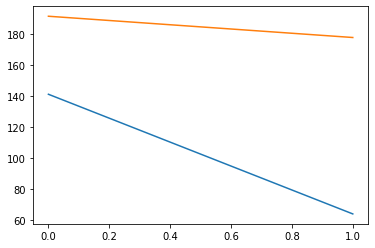

In [78]:
plt.plot(X_test_inverse_diff.flatten())
plt.plot(test_predict_inverse_diff.flatten())

Plotting the model testing visualization

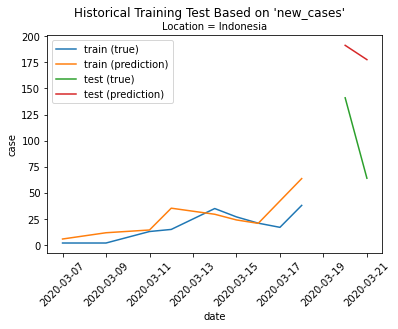

In [79]:
plt.plot(
    diff_cases_index[:len(X_train_inverse_diff.flatten())],
    X_train_inverse_diff.flatten(),
    label='train (true)'
)
plt.plot(
    diff_cases_index[:len(X_train_inverse_diff.flatten())],
    train_predict_inverse_diff.flatten(),
    label='train (prediction)'
)
plt.plot(
    diff_cases_index[
        len(X_train_inverse_diff.flatten()):
        len(X_train_inverse_diff.flatten()) + len(X_test_inverse_diff.flatten())
    ],
    X_test_inverse_diff.flatten(),
    label='test (true)'
)
plt.plot(
    diff_cases_index[
        len(X_train_inverse_diff.flatten()):
        len(X_train_inverse_diff.flatten()) + len(test_predict_inverse_diff.flatten())
    ],
    test_predict_inverse_diff.flatten(),
    label='test (prediction)'
)
plt.suptitle('Historical Training Test Based on \'' + TRAIN_CASE + '\'')
plt.title('Location = ' + TRAIN_LOCATION, fontsize='medium')
plt.xlabel('date')
plt.ylabel('case')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [80]:
return

SyntaxError: 'return' outside function (<ipython-input-80-9b32c1431b19>, line 1)

## Now we'll doing future prediction

Reset LSTM input state for safety

In [ ]:
model.reset_states()

In [ ]:
batch_size = BATCH_SIZE
f_model = Sequential()
f_model.add(LSTM(1, return_sequences=False, 
            batch_input_shape=(batch_size, X_train.shape[1], X_train.shape[2]), 
            stateful=True))
f_model.add(Dense(Y_train.shape[1]))
f_model.compile(loss='mean_squared_error', optimizer='adam')
print(f_model.summary())

Fit the model with all data cases

In [ ]:
epoch = EPOCHS
loss = []
for i in range(epoch):
    print('Iteration ' + str(i + 1) + '/' + str(epoch))
    f_model.fit(X_all, Y_all, batch_size=batch_size, 
              epochs=1, verbose=1, shuffle=False, 
              callbacks=[EarlyStopping(monitor='loss', mode='min', verbose=1)])
    h = f_model.history
    loss.append(h.history['loss'][0])
    f_model.reset_states()

Plotting model loss history

Lower `loss` provides better prediction

In [ ]:
plt.plot(loss, label='loss')
plt.title('Model Loss History')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

Predicting with train data

This will also set prediction input (previous input) into LSTM state which is useful to predict future value

In [ ]:
all_predict = f_model.predict(X_all, batch_size=batch_size)

Predicting future value up to n-days

In our case, we're going to predict up to `DAYS_TO_PREDICT` days in the future

In [ ]:
days_to_predict = DAYS_TO_PREDICT
future_predict = []
pred_samples = all_predict[-1:]
pred_samples = np.array([pred_samples])
for i in range(days_to_predict):
    pred = f_model.predict(pred_samples, batch_size=batch_size)
    pred = np.array(pred).flatten()
    future_predict.append(pred)
    new_samples = np.array(pred_samples).flatten()
    new_samples = np.append(new_samples, [pred])
    new_samples = new_samples[1:]
    pred_samples = np.array(new_samples).reshape(1, 1, 1)
future_predict = np.array(future_predict).reshape(len(future_predict), 1, 1)

Reset LSTM input state for safety

In [ ]:
f_model.reset_states()

Predict using previous future prediction

In [ ]:
f_model.predict(X_all, batch_size=batch_size)
f_future_predict = model.predict(future_predict, batch_size=batch_size)

Reset LSTM input state for safety

In [ ]:
f_model.reset_states()

In [ ]:
X_all_flatten = np.array(scaler.inverse_transform(
    np.array(X_all).reshape(X_all.shape[0], 1)
)).flatten().astype('int')
X_all_flatten = np.absolute(X_all_flatten)
Y_all_flatten = np.array(scaler.inverse_transform(
    np.array(Y_all).reshape(Y_all.shape[0], 1)
)).flatten().astype('int')
Y_all_flatten = np.absolute(Y_all_flatten)
all_predict_flatten = np.array(scaler.inverse_transform(
    np.array(all_predict).reshape(all_predict.shape[0], 1)
)).flatten().astype('int')
all_predict_flatten = np.absolute(all_predict_flatten)
future_predict_flatten = np.array(scaler.inverse_transform(
    np.array(future_predict).reshape(future_predict.shape[0], 1)
)).flatten().astype('int')
future_predict_flatten = np.absolute(future_predict_flatten)
f_future_predict_flatten = np.array(scaler.inverse_transform(
    np.array(f_future_predict).reshape(f_future_predict.shape[0], 1)
)).flatten().astype('int')
f_future_predict_flatten = np.absolute(f_future_predict_flatten)

Getting RMSE scores

In [ ]:
all_predict_score = math.sqrt(
    mean_squared_error(
        Y_all_flatten, 
        all_predict_flatten
    )
)

In [ ]:
'All Score: %.2f RMSE' % (all_predict_score)

Generate future index (dates)

In [ ]:
future_index = pd.date_range(start=cases.index[-1], periods=days_to_predict + 1, closed='right')

Plotting future prediction visualization

In [ ]:
plt.plot(
    future_index,
    future_predict_flatten,
    label='prediction cases'
)
plt.suptitle('Future Prediction Based on \'' + TRAIN_CASE + '\'')
plt.title('Location = ' + TRAIN_LOCATION, fontsize='medium')
plt.xlabel('date')
plt.ylabel('case')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Plotting f_future prediction visualization

In [ ]:
plt.plot(
    future_index,
    f_future_predict_flatten,
    label='f_prediction cases'
)
plt.suptitle('F_Future Prediction Based on Previous Future Prediction')
plt.title('Location = ' + TRAIN_LOCATION, fontsize='medium')
plt.xlabel('date')
plt.ylabel('case')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
plt.plot(
    cases,
    label='actual cases'
)
plt.plot(
    cases.index[:len(X_all_flatten)],
    all_predict_flatten,
    label='actual prediction cases'
)
plt.plot(
    future_index,
    future_predict_flatten,
    label='predict up to ' + str(days_to_predict) + ' days in the future'
)
plt.plot(
    future_index,
    f_future_predict_flatten,
    label='f_future based on previous future prediction'
)
plt.suptitle('Future Prediction Based on \'' + TRAIN_CASE + '\'')
plt.title('Location = ' + TRAIN_LOCATION, fontsize='medium')
plt.xlabel('date')
plt.ylabel('case')
plt.xticks(rotation=45)
plt.legend()
plt.show()